In [9]:
# Include installs here in format !pip install xxxxx. Comment out if not needed for you
#!pip install mlflow
#!pip install kagglehub[pandas-datasets]

In [10]:
# Include Includes here
from concurrent.futures import ThreadPoolExecutor, as_completed
import gc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import sys
import kagglehub
from sklearn.calibration import CalibratedClassifierCV
from kagglehub import KaggleDatasetAdapter
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, auc
)
import mlflow
import mlflow.sklearn
from datetime import datetime
import logging

# Important
- Use MLFLOW for tracking

# 0. Problem Framing
We are using the dataset linked [here](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). This dataset has a feature called `class` which contains the targets for our project. In this feature, an **anomaly** is defined as an instance of credit card fraud and is assigned a value of `1`. All non-anomalous transactions are assigned a value of `0`.

To ensure the best possible results given the information available, we will be using **supervised learning** with the `class` feature as our target variable. We will train three models, `Moving Average Bands`, `kNN`, and `SVM`. These models were selected specifically to compare the performance of statistical, distance-based, and machine learning approaches to anomaly detection. 

The contents of this dataset are wholly numeric results of PCA, except for `amount` and `time `. The original features are not provided to maintain privacy. The data is heavily imbalanced. As such, we will use primarily precision-recall curve for analysis of performance as the confusion matrix will not provide useful results. 
As per the dataset page, the non - PCA features are as follows:

> "Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning."


## Method Discussion and Justification


## Moving Average Bands
-----
### Advantages
### Disadvantages
### Why it is good for this specific problem

## kNN
-----
### Advantages
### Disadvantages
### Why it is good for this specific problem


### SVM
-----
Support vector machines are an approach based on error-based learning. 
They are typically used for classification, regression, and outlier detection.
SVM is a **discriminative** classifier. This means it finds a point/line/plane/etc which divides classes from eachother.

If you draw a decision boundary or separating hyperplane between two classes, the distance from the boundary to the nearest training instance is known as the **margin**.
This can be illustrated using dashed lines known as **margin extents**. We optimize our model by selecting the separation with the greatest margin.

Where $\gamma_i$ is the distance between the boundary and a given point, we can write: 
$$
\gamma_i = y_i(w^Tx_i+b)\quad\quad y_i \in \{-1,1\}
$$

Here, $w$ is the separating hyperplane is given by
$$
b+w^T\cdot x=0
$$

Where $w\cdot d$ is the dot product of the weights and descriptive feature values, plus the bias (intercept).
for SVM, we first need to set the negative target feature level to -1 and the positive to +1. 
The model is then made such that instances with the negative target level output $\le-1$ and positive $\ge+1$.
The in-bewteen area allows for the margin.

Our goal is thus to find $b,w$ to maximize the margin, which can be achieved my minimizing $w$:

$$
\begin{array}{rl}
\textrm{max}_{\gamma,w,b} & \gamma \\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge \gamma,\quad i=1...m\\
\end{array}
$$

$$
\begin{array}{rl}
\textrm{min}_{\gamma,w,b} & \frac{1}{2}||w||^2 \\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge 1,\quad i=1...m\\
\end{array}
$$

A **hard margin** is that which was described above - and is useful in linearly seperable problems. 
We could also consider a **soft margin**, useful in situations where this is not the case or where the hard margin produces a small margin.
In this case, misclassification is allowed and then we minimize the error therein. 
The loss of a misclassified point is called a **slack variable**. 
We can then use the following equation for our problem.
$$
\begin{array}{rl}
\textrm{min}_{\gamma,w,b} & \frac{1}{2}||w||^2 + C \sum^m_{i=1}{\xi_i}\\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge 1,\quad i=1...m\\
\textrm{    } & \xi_m \geq \forall m\\
\end{array}
$$


### Advantages
They are best for high-dimensional spaces and are memory efficient. 

When handling non-linearly separable datasets, we can change the **kernel**. 
This allows us to increase the dimensionality of our problem, helping to identify hyperplanes for classification.
By adjusting  $\gamma$, we can modify how far the influence of a training point is considered. 
The higher we set it, the closer points we consider.

We can vary the hyperparamter C to dictate the level of penalty applied to misclassification. 
A small C value implies no permission for error - or a hard boundary.
A large value of C implies a greater tolerance for misclassification - or a soft boundary.

### Disadvantages
If the number of features is far greater than that of samples, we need to employ regularization to avoid overfitting.
SVMs do not provide probability estimates, instead we need a five-fold cross validation to do this.

SVM is also very sensitive to feature scaling, and we should ensure all features are normalized or standardized.

### Why it is good for this specific problem
For anomaly detection, SVM will generate a decision function that assigns new points a decision score based on how anomalous they are.
By choosing the correct kernel and optimizing our hyperparameters - we are able to create a decision boundary should enclose the majority of the data.

Things to do for pretreating data
- check missing values
- oversample minority class
- split into train and test sets with stratified sampling using sklearn using ten fold cross validation so 10/90


## Data Understanding

# 1.Data Preparation

In [11]:
def get_df():
    # make it so we dont need the local zip
    file_path = "creditcard.csv"
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "mlg-ulb/creditcardfraud",
        file_path,
    )
    return df

In [12]:
df = get_df()

# df = pd.read_csv("creditcard.csv")
rows = df.shape[0] #calculate number of rows
features = df.columns #features
n_features = df.shape[1] #number of features

print(f"Number of samples: {rows}")
print(f"Number of features: {n_features}")

print("\n\033[1m" + "Data types of each feature:" + "\033[0m")
for col in df.columns:
    print(f"\t{col:<10} = {df[col].dtype}")

#identify anomalies:

#find missing values in each feature:
if (df.isnull().any().any()): # If there are actually any missing values
    print(f"\nFeatures with missing values\n:")
    for feat in features:
        missing_nan = df[feat].isnull().sum() #adds all missing values in that column
        if missing_nan > 0:
            missing_per = (missing_nan/rows)*100 #finds the percentage
            print(f"{feat}: NaN = {missing_nan}, NaN% = {missing_per:.2f}%")
else:
    print("There are no missing values")

#find features with only one category (which provides no valuable information):
if (len(df.columns[df.nunique() == 1])>0): # If there are actually any
    print(f"\nFeatures with only one category:\n")
    for feat in features:
        if df[feat].nunique() == 1:
            print(f"{feat}")

df.head()

/tmp/ipykernel_8216/220140001.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Number of samples: 284807
Number of features: 31

Data types of each feature:
	Time       = float64
	V1         = float64
	V2         = float64
	V3         = float64
	V4         = float64
	V5         = float64
	V6         = float64
	V7         = float64
	V8         = float64
	V9         = float64
	V10        = float64
	V11        = float64
	V12        = float64
	V13        = float64
	V14        = float64
	V15        = float64
	V16        = float64
	V17        = float64
	V18        = float64
	V19        = float64
	V20        = float64
	V21        = float64
	V22        = float64
	V23        = float64
	V24        = float64
	V25        = float64
	V26        = float64
	V27        = float64
	V28        = float64
	Amount     = float64
	Class      = int64
There are no missing values


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


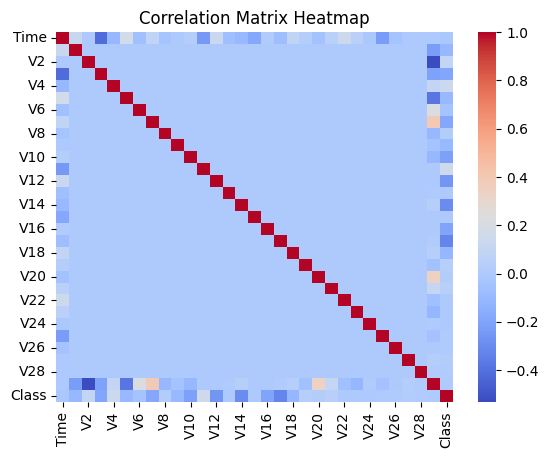

In [13]:
# Correlation matrix
correlation_matrix = df.corr()

sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

A low correlation among features generally implies that the variables are not strongly linearly related to each other. 
This also means that each feature is contributing different, non-redundant information.

To compensate for the severe class imbalance in the data, we will be using a **stratified 5-fold cross validation**. 
This will ensure that each training and validation split preserves the original class distribution.
This ensures that anomalies are represented in every fold, allowing for more reliable evaluation of the model’s detection performance
> MAYBE ADD MORE TO THIS?

## 1.1. Moving Average Bands

## 1.2. kNN

## 1.3. SVM

Robust scaling is used when outliers are real, but scaling is still necessary. 
In the case of supervised anomaly detection, we do not want to remove out anomalies. 
As such, we will use robust scaling - given by:
$$
x'=\frac{x-median(x)}{IQR(x)}
$$

In [14]:
def SVM_preprocess(d):
    X = d.iloc[:, :-1]
    y = d.iloc[:, -1]

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    return X_scaled,y

# 2. Detection Methods


## 2.1. Moving Average Bands

## 2.2. kNN

## 2.3. SVM

In [ ]:

def SVM_run(params, d, experiment_name):

    mlflow.set_experiment(experiment_name)


    run_name = f"SVM_k={params['kernel']}_C={params['C']:.2g}"
    
    print(f"\n{run_name}")
    print(datetime.now())

    with mlflow.start_run(run_name=run_name):

        # Preprocess
        X, y = SVM_preprocess(d)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Log params
        mlflow.log_params(params)

        # Build model
        model = SVC(
            kernel=params["kernel"],
            C=params["C"],
            degree=params.get("degree", 3),
            gamma=params.get("gamma", "scale"),
            probability=True,
            random_state=42
        )


        # Predictions - Slow step
        probs = cross_val_predict(model, X, y, cv=skf, method="predict_proba",n_jobs=-1)

        thresholds = np.arange(0.0, 1.01, 0.05)
        y_proba = probs[:, 1]
        for threshold in thresholds:

            y_pred = (y_proba >= threshold).astype(int)

            # Metrics
            precision = precision_score(y, y_pred)
            recall = recall_score(y, y_pred)
            f1 = f1_score(y, y_pred)

            mlflow.log_metric(f"t{threshold:.2f}_precision", precision)
            mlflow.log_metric(f"t{threshold:.2f}_recall", recall)
            mlflow.log_metric(f"t{threshold:.2f}_f1_score", f1)

            # cm
            cm = confusion_matrix(y, y_pred)
            tn, fp, fn, tp = cm.ravel()
            mlflow.log_metric(f"t{threshold:.2f}_fp", fp)
            mlflow.log_metric(f"t{threshold:.2f}_fn", fn)
            mlflow.log_metric(f"t{threshold:.2f}_tn", tn)
            mlflow.log_metric(f"t{threshold:.2f}_tp", tp)

        # ROC
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)

        mlflow.log_metric(f"roc_auc", roc_auc)


        # Fit + log model
        model.fit(X, y)
        mlflow.sklearn.log_model(model, name=f"SVM_{params['kernel']}")
        

    return 

# 3. Threshold Optimization
- Optimizing to reduce false negatives
- Confusion matrix less important here
- AUC more important
- Analyze anomaly score distributions
- Select and justify detection threshold
- Perform sensitivity analysis on threshold selection
- Priority = recall

## 3.1. Moving Average Bands

## 3.2. kNN

## 3.3. SVM

In [ ]:
C_values = np.logspace(-5, 0, 15)
gamma_values = np.logspace(-6, 1, 15)

kernels = ["linear", "rbf","poly", "sigmoid"]
degrees = [2, 3, 4, 5]

param_grid = []

def param_generator():
    for kernel in kernels:
        for C in C_values:
            if kernel == "linear":
                yield {"kernel": kernel, "C": float(C)}

            elif kernel == "poly":
                for gamma in gamma_values:
                    for degree in degrees:
                        yield {
                            "kernel": kernel,
                            "C": float(C),
                            "gamma": float(gamma),
                            "degree": degree,
                        }

            else:  # rbf, sigmoid
                for gamma in gamma_values:
                    yield {
                        "kernel": kernel,
                        "C": float(C),
                        "gamma": float(gamma),
                    }


df = get_df()

# Function wrapper for try-except
def run_svm(params):
    try:
        SVM_run(params, df, "SVM_v1_local")
    except Exception as e:
        return f"ERROR with {params}: {e}"
    return f"SUCCESS with {params}"

def chunked(iterable, batch_size):
    batch = []
    for item in iterable:
        batch.append(item)
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

# run
for batch in chunked(param_generator(), 4):

    with ThreadPoolExecutor(max_workers=2) as executor:
        futures = [executor.submit(run_svm, p) for p in batch]

        for future in as_completed(futures):
            result = future.result()
            if result.startswith("ERROR"):
                print(result)

    # cleanup after each batch
    del futures
    del batch
    gc.collect()

/tmp/ipykernel_8216/220140001.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(



SVM_k=linear_C=1e-05_t=0

SVM_k=linear_C=1e-05_t=0.05
SVM_k=linear_C=1e-05_t=0 Preprocessing Success
SVM_k=linear_C=1e-05_t=0.05 Preprocessing Success
SVM_k=linear_C=1e-05_t=0 Param Log Success
SVM_k=linear_C=1e-05_t=0 Model Build Success
SVM_k=linear_C=1e-05_t=0.05 Param Log Success
SVM_k=linear_C=1e-05_t=0.05 Model Build Success
SVM_k=linear_C=1e-05_t=0 Predict Success
SVM_k=linear_C=1e-05_t=0 Metric Calc Success
SVM_k=linear_C=1e-05_t=0 Metric Log Success
SVM_k=linear_C=1e-05_t=0 CM Calc Success
SVM_k=linear_C=1e-05_t=0 FPR Log Success
SVM_k=linear_C=1e-05_t=0 ROC/AUC Calc Success
SVM_k=linear_C=1e-05_t=0 ROC/AUC Log Success
SVM_k=linear_C=1e-05_t=0 PR Curve Calc Success
SVM_k=linear_C=1e-05_t=0.05 Predict Success
SVM_k=linear_C=1e-05_t=0.05 Metric Calc Success
SVM_k=linear_C=1e-05_t=0.05 Metric Log Success
SVM_k=linear_C=1e-05_t=0.05 CM Calc Success
SVM_k=linear_C=1e-05_t=0.05 FPR Log Success
SVM_k=linear_C=1e-05_t=0.05 ROC/AUC Calc Success
SVM_k=linear_C=1e-05_t=0.05 ROC/AUC Log 

2026/04/18 13:03:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM_k=linear_C=1e-05_t=0 Model Log Success

SVM_k=linear_C=1e-05_t=0.1
SVM_k=linear_C=1e-05_t=0.1 Preprocessing Success
SVM_k=linear_C=1e-05_t=0.1 Param Log Success
SVM_k=linear_C=1e-05_t=0.1 Model Build Success


2026/04/18 13:04:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

SVM_k=linear_C=5.2e-05_t=0.05 Model Log Success

SVM_k=linear_C=5.2e-05_t=0.15

SVM_k=linear_C=5.2e-05_t=0.1
SVM_k=linear_C=5.2e-05_t=0.15 Preprocessing Success
SVM_k=linear_C=5.2e-05_t=0.15 Param Log Success
SVM_k=linear_C=5.2e-05_t=0.15 Model Build Success
SVM_k=linear_C=5.2e-05_t=0.1 Preprocessing Success
SVM_k=linear_C=5.2e-05_t=0.1 Param Log Success
SVM_k=linear_C=5.2e-05_t=0.1 Model Build Success
SVM_k=linear_C=5.2e-05_t=0.1 Predict Success
SVM_k=linear_C=5.2e-05_t=0.1 Metric Calc Success
SVM_k=linear_C=5.2e-05_t=0.1 Metric Log Success
SVM_k=linear_C=5.2e-05_t=0.1 CM Calc Success
SVM_k=linear_C=5.2e-05_t=0.1 FPR Log Success
SVM_k=linear_C=5.2e-05_t=0.1 ROC/AUC Calc Success
SVM_k=linear_C=5.2e-05_t=0.1 ROC/AUC Log Success
SVM_k=linear_C=5.2e-05_t=0.1 PR Curve Calc Success
SVM_k=linear_C=5.2e-05_t=0.15 Predict Success
SVM_k=linear_C=5.2e-05_t=0.15 Metric Calc Success
SVM_k=linear_C=5.2e-05_t=0.15 Metric Log Success
SVM_k=linear_C=5.2e-05_t=0.15 CM Calc Success
SVM_k=linear_C=5.2e-0

2026/04/18 17:36:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM_k=linear_C=5.2e-05_t=0.1 Model Log Success

SVM_k=linear_C=5.2e-05_t=0.2
SVM_k=linear_C=5.2e-05_t=0.2 Preprocessing Success
SVM_k=linear_C=5.2e-05_t=0.2 Param Log Success
SVM_k=linear_C=5.2e-05_t=0.2 Model Build Success


2026/04/18 17:36:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM_k=linear_C=5.2e-05_t=0.15 Model Log Success

SVM_k=linear_C=5.2e-05_t=0.25
SVM_k=linear_C=5.2e-05_t=0.25 Preprocessing Success
SVM_k=linear_C=5.2e-05_t=0.25 Param Log Success
SVM_k=linear_C=5.2e-05_t=0.25 Model Build Success
SVM_k=linear_C=5.2e-05_t=0.2 Predict Success
SVM_k=linear_C=5.2e-05_t=0.2 Metric Calc Success
SVM_k=linear_C=5.2e-05_t=0.2 Metric Log Success
SVM_k=linear_C=5.2e-05_t=0.2 CM Calc Success
SVM_k=linear_C=5.2e-05_t=0.2 FPR Log Success
SVM_k=linear_C=5.2e-05_t=0.2 ROC/AUC Calc Success
SVM_k=linear_C=5.2e-05_t=0.2 ROC/AUC Log Success
SVM_k=linear_C=5.2e-05_t=0.2 PR Curve Calc Success
SVM_k=linear_C=5.2e-05_t=0.25 Predict Success
SVM_k=linear_C=5.2e-05_t=0.25 Metric Calc Success
SVM_k=linear_C=5.2e-05_t=0.25 Metric Log Success
SVM_k=linear_C=5.2e-05_t=0.25 CM Calc Success
SVM_k=linear_C=5.2e-05_t=0.25 FPR Log Success
SVM_k=linear_C=5.2e-05_t=0.25 ROC/AUC Calc Success
SVM_k=linear_C=5.2e-05_t=0.25 ROC/AUC Log Success
SVM_k=linear_C=5.2e-05_t=0.25 PR Curve Calc Success

# 4. Evaluation
- Precision, Recall, F1-score
- ROC curve and PR curve
- Confusion matrix at selected threshold
- False positive rate analysis

## 4.1. MAB

## 4.2. kNN

## 4.3. SVM

# 5. Interperabiltiy

# Reflection
- Trade-offs in threshold selection
- Impact of imbalance
- Failure scenarios in production
- Monitoring and retraining strategy
- Logged experiments
- Discussion of production risks and monitoring